# Diagnostics · Stream-crossing filter QA

**Primary interface** for inspecting pairs removed by the Mars stream-crossing
filter. Calls `channel_heads.*` only:

- `channel_heads.pairing.detect_crossed_segments` — which network segments the
  head-to-head straight line crosses (mirrors the feature-pipeline filter)
- `channel_heads.viz.plot_removed_pair` / `removed_pair_legend_handles` — the QA
  panel renderer

It is **read-only**: it renders a few removed pairs inline and writes nothing.

> Uses the all-pairs feature table (with the `stream_crossing_drop` flag) +
> topology + pair paths.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from channel_heads.config import PROJECT_ROOT
from channel_heads.pairing import detect_crossed_segments
from channel_heads.viz import plot_removed_pair, removed_pair_legend_handles

FEATURES = PROJECT_ROOT / "data/Mars/model_inputs/mars_pair_features_5feat_all.parquet"
TOPOLOGY_GPKG = PROJECT_ROOT / "data/Mars/topology/mars_vn_topology_model_ready.gpkg"
PAIRS_GPKG = PROJECT_ROOT / "data/Mars/topology/mars_vn_pairs.gpkg"
N_PANELS = 6
SEED = 42

have_data = FEATURES.exists() and TOPOLOGY_GPKG.exists() and PAIRS_GPKG.exists()
print("inputs present:", have_data)

inputs present: True


## Sample removed pairs + build lookups (read-only)

In [2]:
if have_data:
    feats = pd.read_parquet(FEATURES)
    removed = feats[feats["stream_crossing_drop"]].sample(N_PANELS, random_state=SEED)

    nodes_gdf = gpd.read_file(TOPOLOGY_GPKG, layer="mars_nodes")
    segs_gdf = gpd.read_file(TOPOLOGY_GPKG, layer="mars_segments")
    pair_paths = gpd.read_file(PAIRS_GPKG, layer="mars_pair_paths")
    try:
        outlets_gdf = gpd.read_file(TOPOLOGY_GPKG, layer="mars_outlets")
        outlets_by_nid = {int(r["network_id"]): (float(r.geometry.x), float(r.geometry.y))
                          for _, r in outlets_gdf.iterrows()}
    except Exception:
        outlets_by_nid = {}

    nodes_by_nid = dict(tuple(nodes_gdf.groupby("network_id")))
    segs_by_nid = dict(tuple(segs_gdf.groupby("network_id")))
    paths_by_pair_branch = {(str(r["pair_id"]), str(r["branch"])): r.geometry
                            for _, r in pair_paths.iterrows()}
    print(f"{int(feats['stream_crossing_drop'].sum())} removed pairs total; "
          f"rendering {len(removed)}")
else:
    print("inputs absent — skipping")

11892 removed pairs total; rendering 6


## Render removed-pair QA panels inline

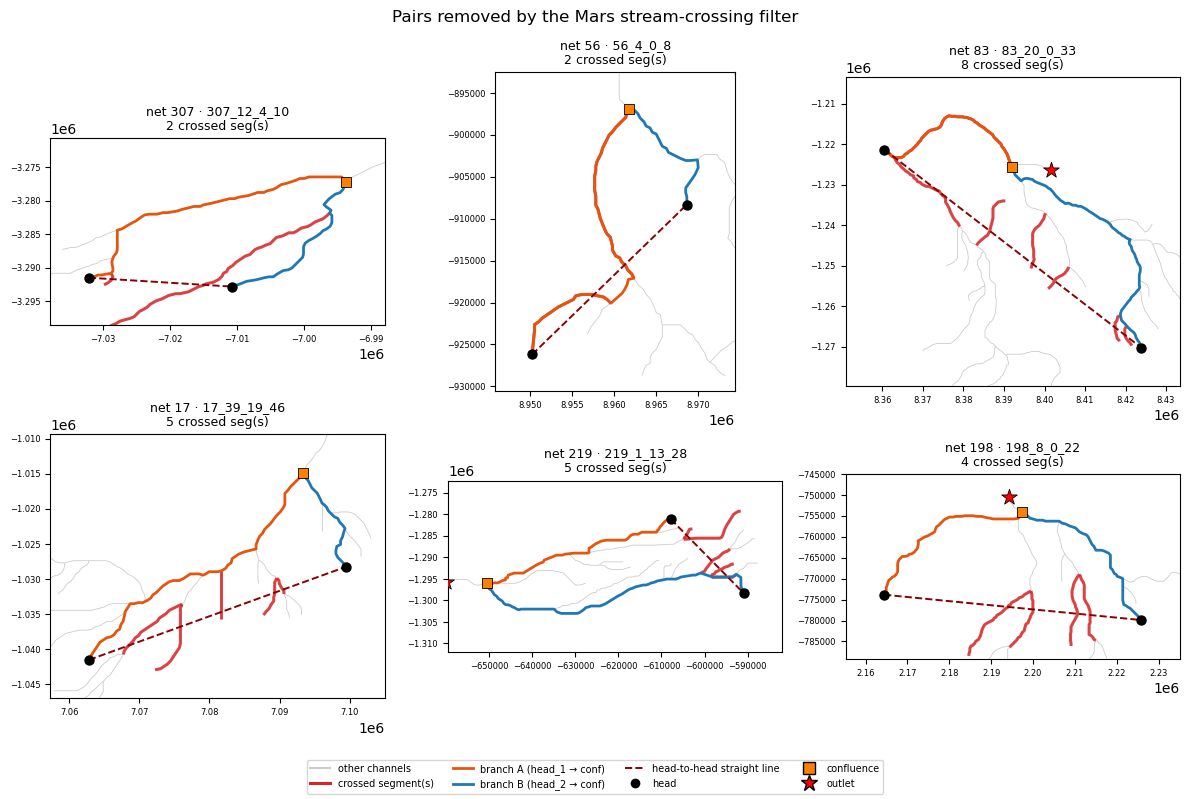

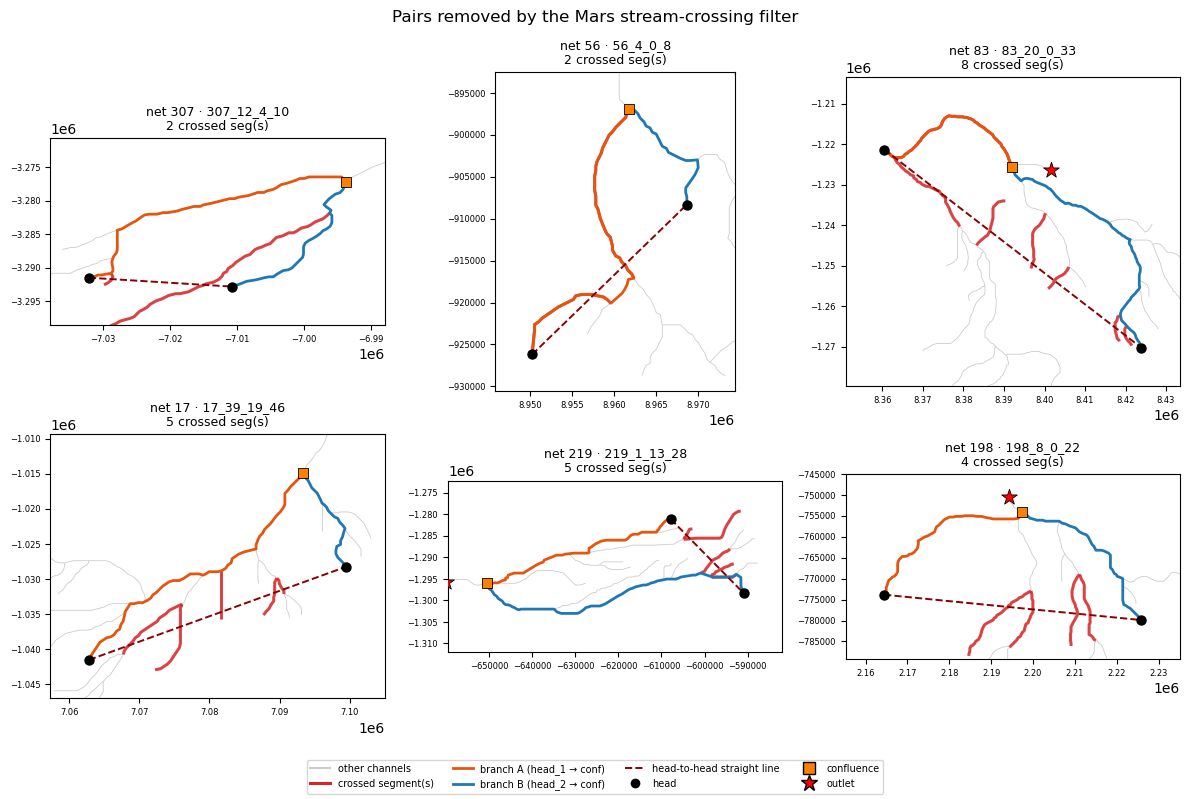

In [3]:
if have_data:
    cols = 3
    rows = int(np.ceil(len(removed) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.0, rows * 4.0))
    axes_flat = np.atleast_1d(axes).ravel()
    for ax, (_, srow) in zip(axes_flat, removed.iterrows()):
        nid = int(srow["network_id"]); pair_id = str(srow["pair_id"])
        nodes_n = nodes_by_nid[nid]; segs_n = segs_by_nid[nid]
        node_xy = {int(r["node_id"]): (float(r.geometry.x), float(r.geometry.y))
                   for _, r in nodes_n.iterrows()}
        h1_xy = node_xy[int(srow["head_node_id_1"])]
        h2_xy = node_xy[int(srow["head_node_id_2"])]
        conf_xy = node_xy[int(srow["confluence_node_id"])]
        path_a = paths_by_pair_branch.get((pair_id, "A"))
        path_b = paths_by_pair_branch.get((pair_id, "B"))
        if path_a is None or path_b is None:
            ax.set_visible(False); continue
        crossed = detect_crossed_segments(h1_xy, h2_xy, segs_n)
        plot_removed_pair(ax, srow, segs_n, path_a, path_b, h1_xy, h2_xy, conf_xy,
                          outlets_by_nid.get(nid), crossed,
                          title=f"net {nid} · {pair_id}\n{len(crossed)} crossed seg(s)")
    for ax in axes_flat[len(removed):]:
        ax.set_visible(False)
    fig.legend(handles=removed_pair_legend_handles(), loc="lower center", ncol=4, fontsize=7)
    fig.suptitle("Pairs removed by the Mars stream-crossing filter", fontsize=12)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
else:
    fig = None
    print("Run: python scripts/diagnostics/qa_mars_stream_crossing_filter.py")
fig

---
Full QA run (writes the contact sheet + GeoPackage):

```bash
python scripts/diagnostics/qa_mars_stream_crossing_filter.py
```